# Машинное обучение. Курсовая работа

Датасет ["Support Ticket Priority Dataset (50k)"](https://www.kaggle.com/datasets/albertobircoci/support-ticket-priority-dataset-50k) представляет собой синтетический, но реалистично смоделированный набор данных, имитирующий работу IT-сервисной дески (Service Desk) или службы поддержки компании. Датасет содержит 50 000 записей об обращениях (тикетах) в службу поддержки. 

## Предобработка и анализ данных

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv("../data/Support_tickets.csv")
df.head(5)

,ticket_id,day_of_week,day_of_week_num,company_id,company_size,company_size_cat,industry,industry_cat,customer_tier,customer_tier_cat,...,downtime_min,payment_impact_flag,security_incident_flag,data_loss_flag,has_runbook,customer_sentiment,customer_sentiment_cat,description_length,priority,priority_cat
0,1000000000,Wed,3,100015,Small,1,media,7,Basic,1,...,6,0,0,0,0,neutral,2,227,low,1
1,1000000001,Sat,6,100023,Small,1,healthcare,5,Basic,1,...,2,0,0,0,0,neutral,2,461,low,1
2,1000000002,Mon,1,100012,Small,1,gaming,4,Basic,1,...,0,0,0,0,1,positive,3,306,low,1
3,1000000003,Wed,3,100003,Small,1,media,7,Plus,2,...,16,0,0,0,1,neutral,2,363,medium,2
4,1000000004,Mon,1,100019,Small,1,ecommerce,2,Plus,2,...,6,0,0,0,0,neutral,2,442,low,1


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ticket_id               50000 non-null  int64  
 1   day_of_week             50000 non-null  object 
 2   day_of_week_num         50000 non-null  int64  
 3   company_id              50000 non-null  int64  
 4   company_size            50000 non-null  object 
 5   company_size_cat        50000 non-null  int64  
 6   industry                50000 non-null  object 
 7   industry_cat            50000 non-null  int64  
 8   customer_tier           50000 non-null  object 
 9   customer_tier_cat       50000 non-null  int64  
 10  org_users               50000 non-null  int64  
 11  region                  50000 non-null  object 
 12  region_cat              50000 non-null  int64  
 13  past_30d_tickets        50000 non-null  int64  
 14  past_90d_incidents      50000 non-null

In [3]:
# В датасете категориальные признаки уже имеют закодированные числовые признаки,
# поэтому копируем датасет, но только с числовыми признаками
df.drop(columns="ticket_id", inplace=True)
print("\nDropped the non-informative identifying column: row_id")
num_df = df.select_dtypes(include=["number"]).copy()
num_df.info()


Dropped the non-informative identifying column: row_id
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day_of_week_num         50000 non-null  int64  
 1   company_id              50000 non-null  int64  
 2   company_size_cat        50000 non-null  int64  
 3   industry_cat            50000 non-null  int64  
 4   customer_tier_cat       50000 non-null  int64  
 5   org_users               50000 non-null  int64  
 6   region_cat              50000 non-null  int64  
 7   past_30d_tickets        50000 non-null  int64  
 8   past_90d_incidents      50000 non-null  int64  
 9   product_area_cat        50000 non-null  int64  
 10  booking_channel_cat     50000 non-null  int64  
 11  reported_by_role_cat    50000 non-null  int64  
 12  customers_affected      50000 non-null  int64  
 13  error_rate_pct          50000 non-n

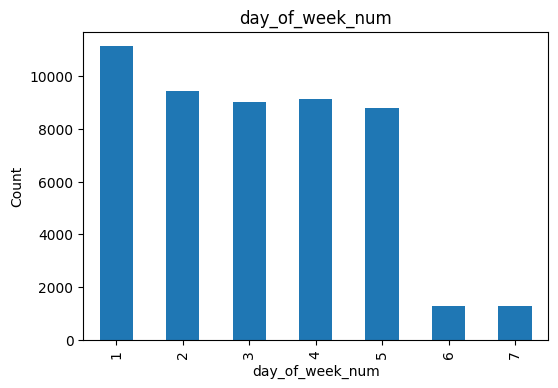

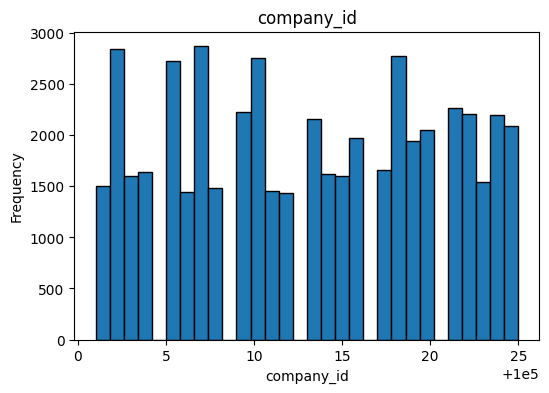

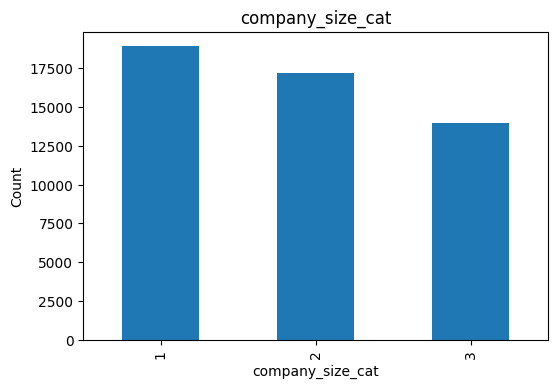

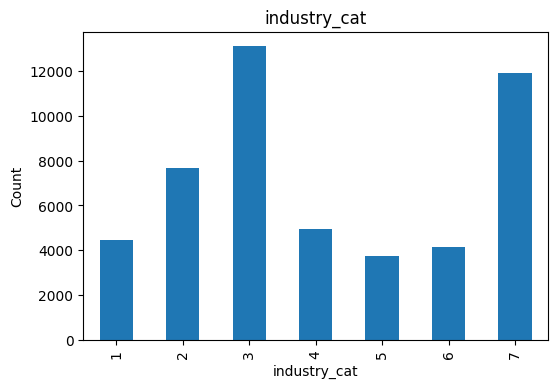

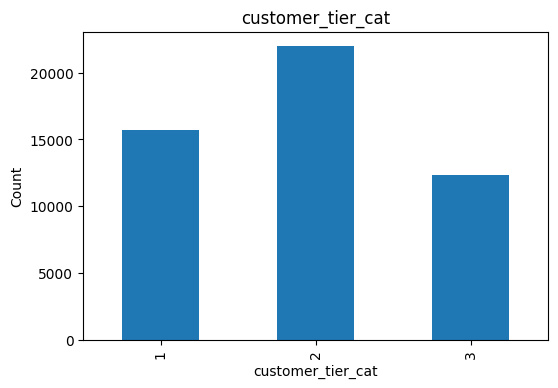

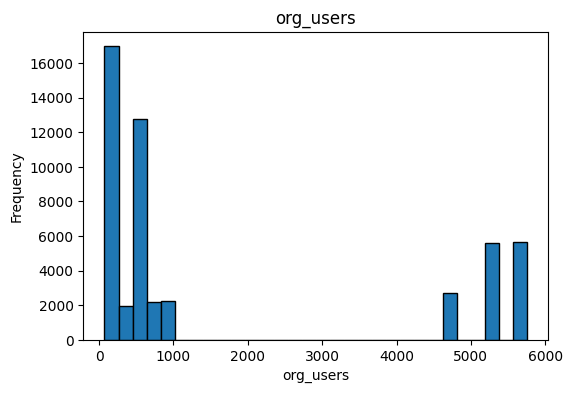

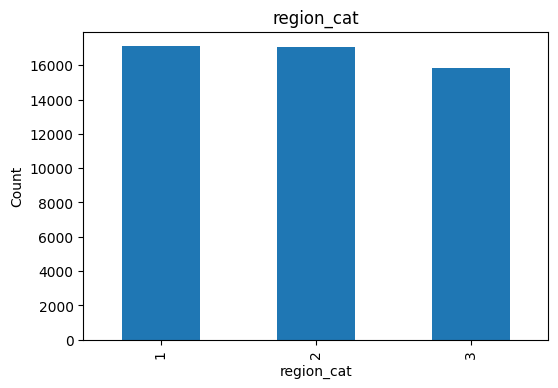

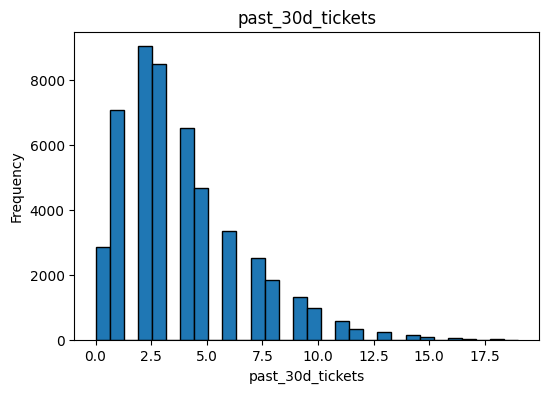

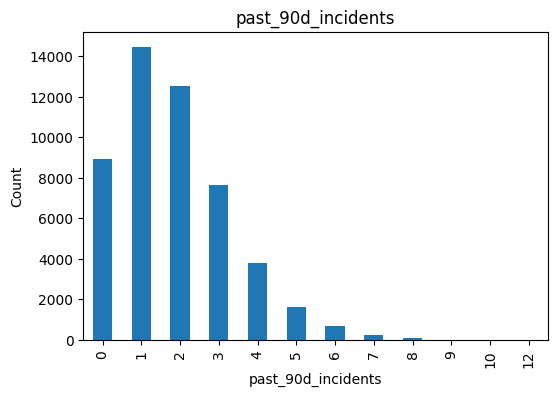

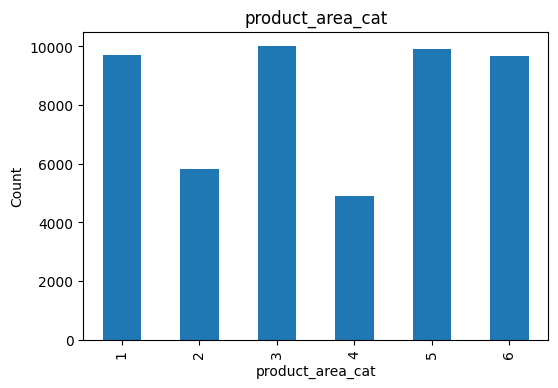

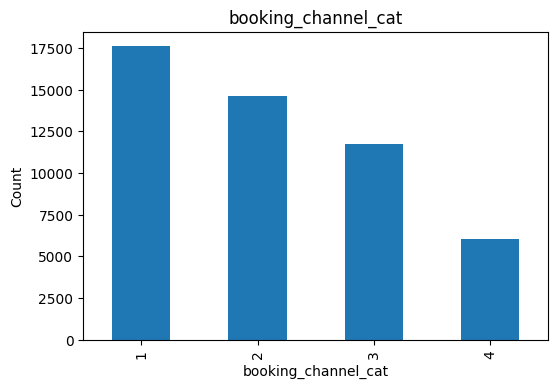

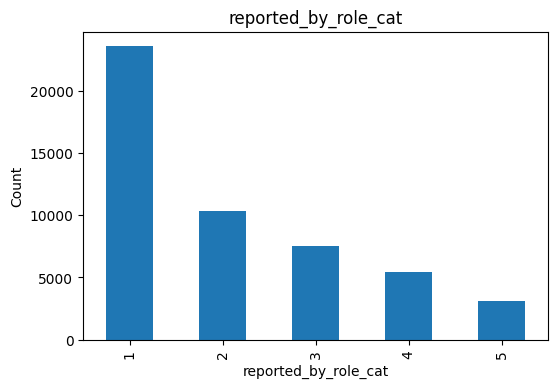

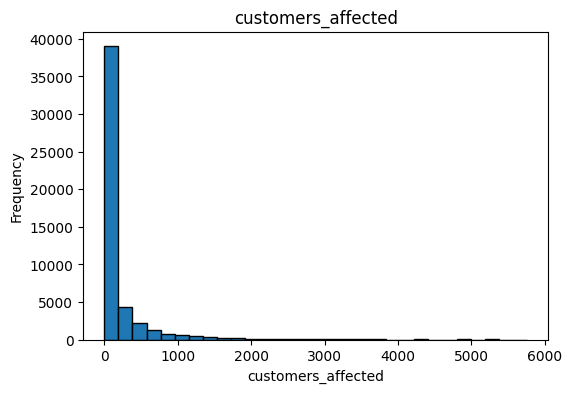

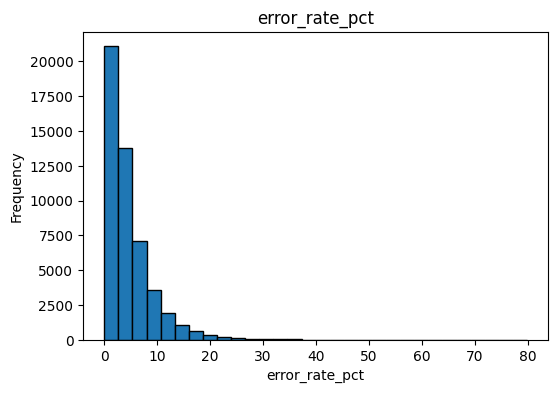

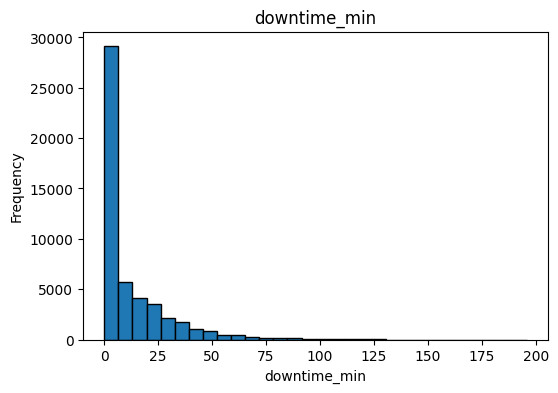

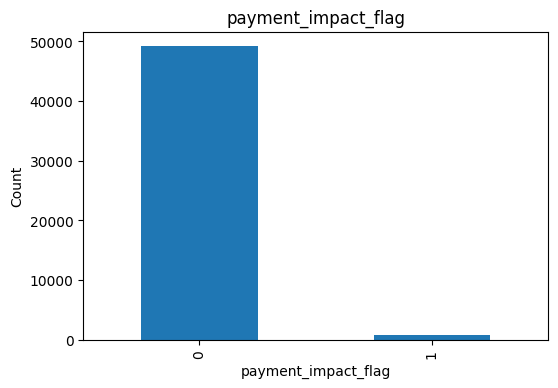

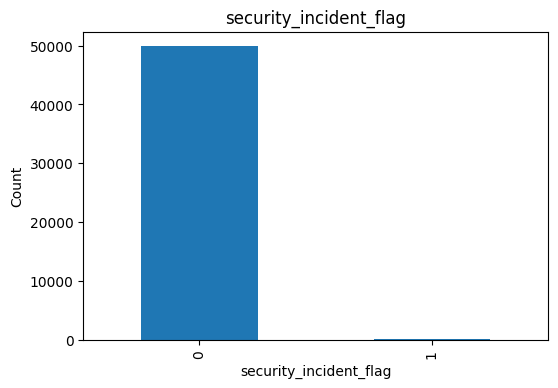

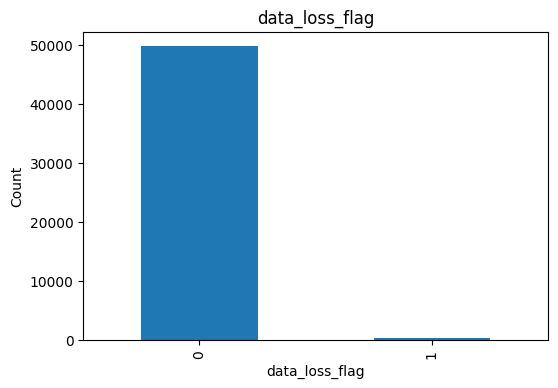

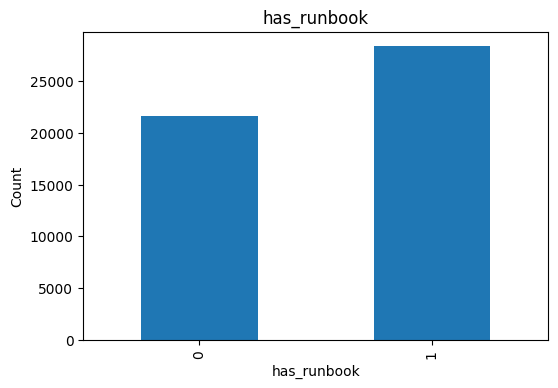

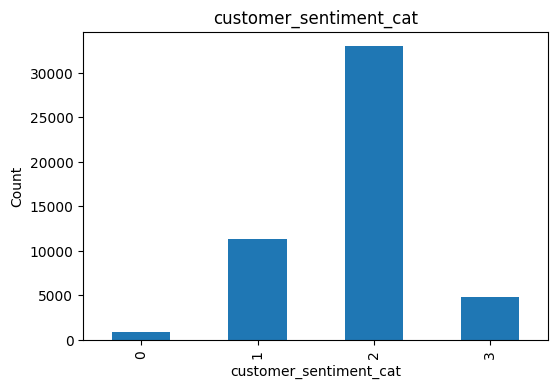

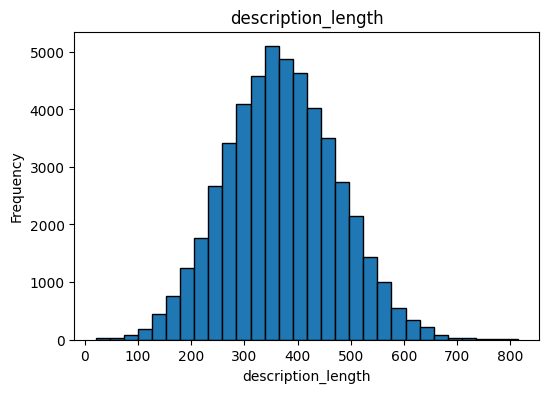

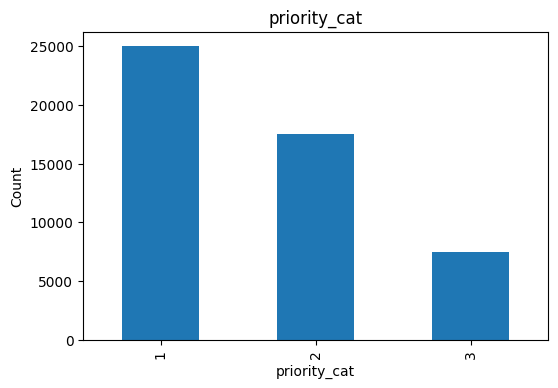

In [4]:
# Гистограммы числовых признаков
import matplotlib.pyplot as plt

for col in num_df.columns:
    plt.figure(figsize=(6, 4))
    if num_df[col].nunique() <= 15:
        num_df[col].value_counts().sort_index().plot(kind="bar")
        plt.ylabel("Count")
    else:
        num_df[col].plot(kind="hist", bins=30, edgecolor="black")
        plt.ylabel("Frequency")
    plt.title(col)
    plt.xlabel(col)
    plt.show()

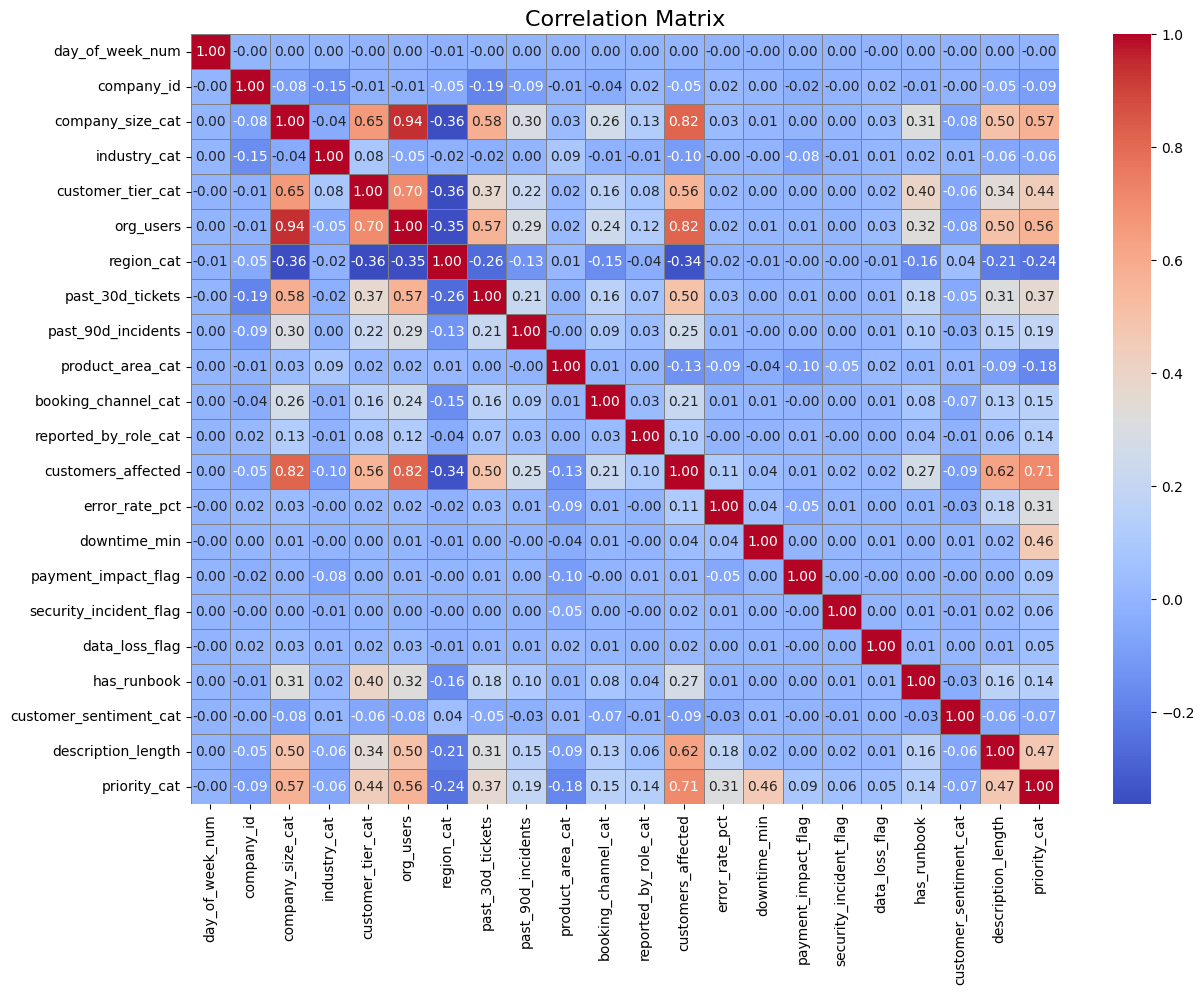

In [5]:
# Тепловая карта корелляций числовых признаков
import seaborn as sns

corr = num_df.corr(numeric_only=True, method="spearman")

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, linecolor="gray", cbar=True
)
plt.title("Correlation Matrix", fontsize=16)
plt.show()

По тепловой карте видно, что категориальный признак размера компании сильно (0.89) кореллирует с параметром org_users, поэтому его можно убрать за избыточностью

In [6]:
num_df.drop(columns="org_users", inplace=True)

## Обучение классификатора

Релевантные метрики для оценки модели:
- Accuracy: стандартная оценка точности
- F1-score (macro): Основная метрика. Она учитывает как точность (precision), так и полноту (recall) и хорошо работает с дисбалансом.
- Confusion Matrix (Матрица ошибок): Поможет понять, какие классы модель путает чаще всего.

In [7]:
import shap
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

from optuna_search import OptunaSearchCV

shap.initjs()

c:\Users\kiril\OneDrive\Documents\Projects\SupportTickets-Prioritization\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
X = num_df.drop(columns=["priority_cat"])
y = num_df["priority_cat"].astype(int) - 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)

In [9]:
model_classes = ["XGBClassifier"]

OS = OptunaSearchCV(model_classes)
OS.fit(X_train, y_train, X_val, y_val, n_trials=100, n_startup_trials=10)
model = OS.best_models[0]
OS.results_df.to_csv("../data/results.csv")


XGBClassifier hyperoptimization


Best trial: 90. Best value: 0.975455: 100%|██████████| 100/100 [07:15<00:00,  4.35s/it]


In [10]:
y_pred = model.predict(X_test)

Prediction Accuracy: 0.9824
F1: 0.9797443199434929


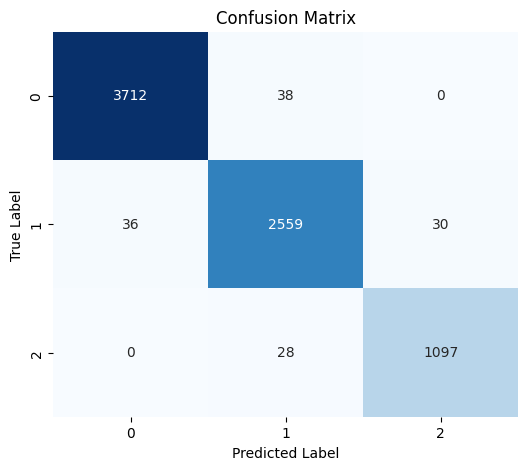

In [11]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")
print("Prediction Accuracy:", accuracy)
print("F1:", f1)

cmatrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cmatrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

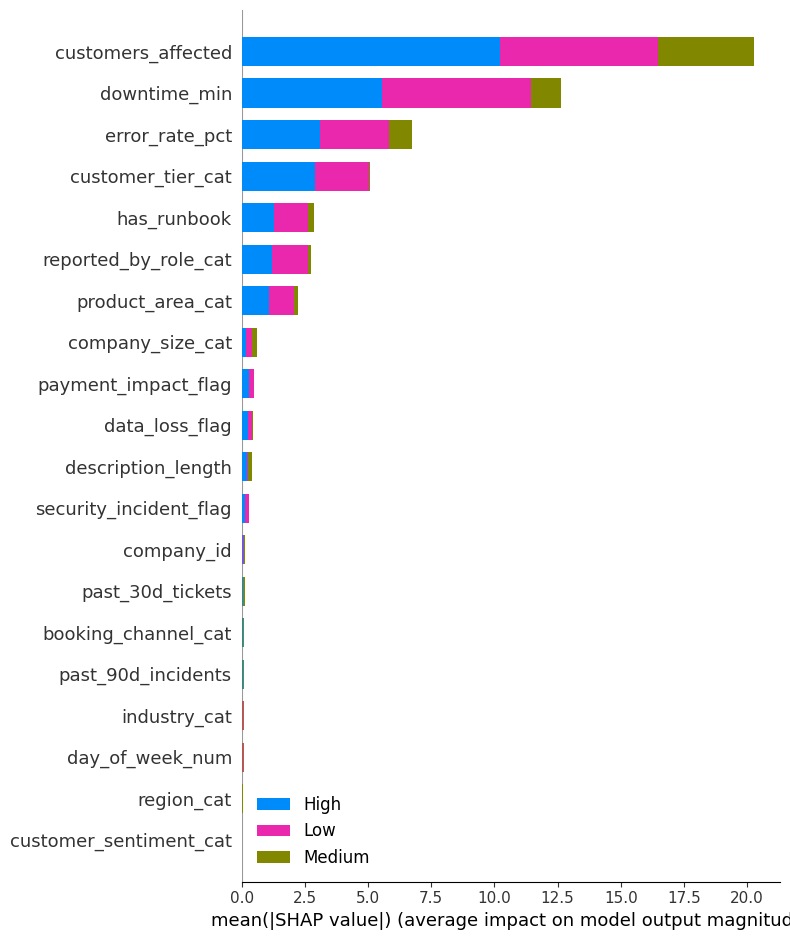

In [12]:
X_explain = X_train.iloc[:100]

feature_names = list(num_df.columns)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_explain)
shap_importance = np.abs(shap_values).mean(axis=0)
shap_exp = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_test,
    feature_names=feature_names,
)

shap.summary_plot(shap_values, X_explain, plot_type="bar", class_names=["Low", "Medium", "High"])